In [2]:
from google.colab import files
uploaded = files.upload()

Saving listings.csv to listings.csv


In [3]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("listings.csv")

keep_cols = ["id", "name", "host_id", "host_name", "neighbourhood",
             "room_type", "price", "minimum_nights", "number_of_reviews",
             "reviews_per_month", "availability_365"]
df = df[[c for c in keep_cols if c in df.columns]]

if df["price"].dtype == object:
    df["price"] = df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False).astype(float)

df = df.dropna(subset=["price"])
df = df[df["price"] > 0]

conn = sqlite3.connect("airbnb.db")
df.to_sql("listings", conn, if_exists="replace", index=False)
print(f"Loaded {len(df)} listings")

Loaded 31964 listings


In [5]:
q1 = """
SELECT neighbourhood, ROUND(AVG(price), 2) AS avg_price, COUNT(*) AS num_listings
FROM listings
GROUP BY neighbourhood
HAVING num_listings >= 5
ORDER BY avg_price DESC
LIMIT 15
"""
df1 = pd.read_sql_query(q1, conn)
df1

,neighbourhood,avg_price,num_listings
0,"Joá, Rio de Janeiro, Brazil",2526.23,26
1,"Río de Janeiro, Rio de Janeiro, Brazil",2020.80,5
2,"São Conrado, Rio de Janeiro, Brazil",1589.32,37
3,"Jardim Botânico, Rio de Janeiro, Brazil",1428.06,48
4,"Santa Cruz, Rio de Janeiro, Brazil",1314.50,6
5,"Gávea, Rio de Janeiro, Brazil",1067.74,39
6,"Recreio dos Bandeir, Rio de Janeiro, Brazil",1002.80,5
7,None,961.45,15225
8,"Paquetá, Rio de Janeiro, Brazil",915.84,19
9,"Rio De Janeiro, Rj, Brazil",908.95,19


/tmp/ipykernel_779/1887668534.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df1, x="avg_price", y="neighbourhood", palette="viridis")


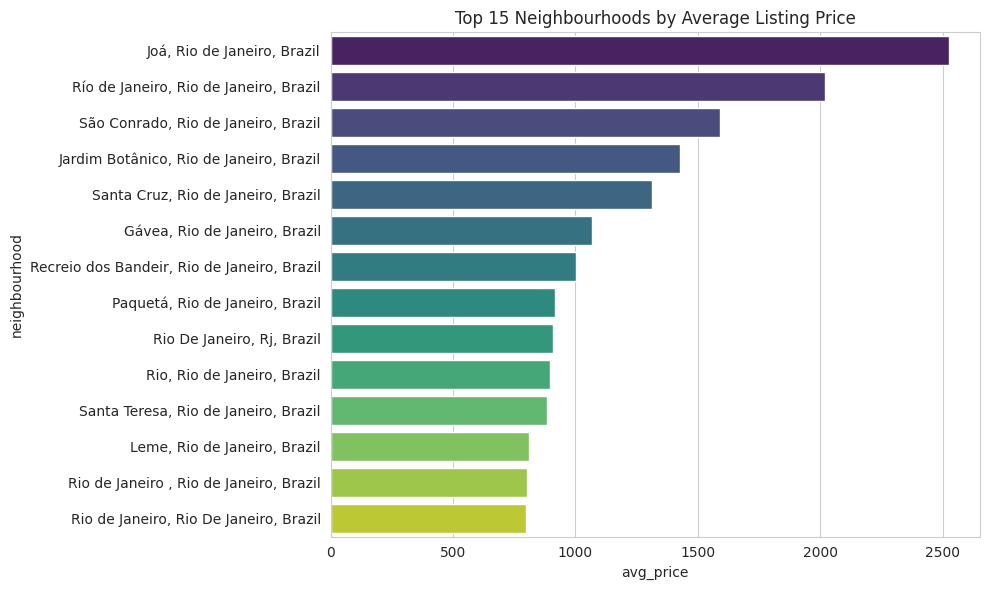

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x="avg_price", y="neighbourhood", palette="viridis")
plt.title("Top 15 Neighbourhoods by Average Listing Price")
plt.tight_layout()
plt.savefig("price_by_neighbourhood.png", dpi=150)
plt.show()

In [7]:
from google.colab import files
files.download("price_by_neighbourhood.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>